# 03 — Debt dynamics and the decomposition of the interest burden

**Question.** Notebook 01 showed the burden falling from the mid-1990s, doubling
through the sovereign-debt crisis, and then falling again. This notebook asks
*why*, using two exact decompositions.

1. **Why the burden moved.** The interest ratio is the effective rate times the
   debt stock relative to GDP. The change in a product splits exactly into a
   rate term, a stock term, and an interaction term.
2. **Why the debt ratio moved.** The change in the debt ratio splits into the
   interest-growth differential acting on inherited debt, the primary balance,
   and the stock-flow adjustment.

Both decompositions are computed by the project library
(`pt_debt_interest.interest_decomposition` and `metrics.calculate_metrics`) and
persisted into the dataset. This notebook **verifies** them — reproducing the
first from the library function and checking both residuals against zero — and
then interprets them. It does not reimplement the formulas, so the notebook and
the generated paper cannot drift apart.

**Scope.** Harmonised ESA 2010 rows only. Lagged terms are undefined in the
first year and are dropped rather than imputed — see
[02 — data quality](02_data_quality_and_provenance.ipynb).

In [1]:
# Run correctly whether the kernel starts in notebooks/ or the repository root.
# Importing nbtools then puts src/ on the path, so pt_debt_interest is
# importable from a plain checkout without an editable install.
import sys
from pathlib import Path

_HERE = Path.cwd() if (Path.cwd() / "nbtools.py").is_file() else Path.cwd() / "notebooks"
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import nbtools as nb
from pt_debt_interest.interest_decomposition import build_interest_burden_decomposition

nb.use_style()
ROOT = nb.repo_root()

df = nb.observed(nb.main_series(nb.load_dataset(ROOT)))
settings = nb.load_settings(ROOT)

print(f"Rows: {len(df)}  years: {int(df['year'].min())}-{int(df['year'].max())}")
print(f"Identity tolerance in config: {settings.analysis.identity_tolerance_pp} pp")

Rows: 31  years: 1995-2025
Identity tolerance in config: 0.05 pp


## 1. There are two effective interest rates, and they answer different questions

The dataset carries both, named for what they are for rather than collapsed into
one ambiguous "implicit rate":

| Column | Denominator | Used for |
| --- | --- | --- |
| `implicit_interest_rate_average_debt_pct` | mean of debt at *t-1* and *t* | the cost of the stock actually outstanding during the year |
| `effective_interest_rate_debt_dynamics_pct` | debt at *t-1* | the debt-dynamics identity, which accrues interest on inherited debt |

Using the wrong one silently breaks whichever identity it feeds. The two differ
by roughly half the year's growth in the stock, so they diverge exactly when the
debt stock is moving fast — which is when the decomposition matters most.

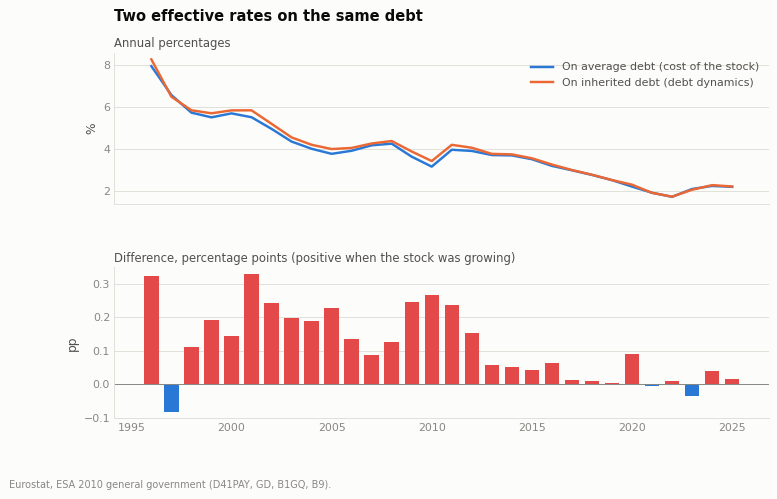

Largest gap: 0.33 pp in 2001


In [3]:
rates = df.dropna(subset=["implicit_interest_rate_average_debt_pct"]).copy()
rates["difference_pp"] = (
    rates["effective_interest_rate_debt_dynamics_pct"]
    - rates["implicit_interest_rate_average_debt_pct"]
)

fig, axes = nb.figure(height=5.4, nrows=2, sharex=True)

axes[0].plot(
    rates["year"],
    rates["implicit_interest_rate_average_debt_pct"],
    color=nb.SERIES[0],
    label="On average debt (cost of the stock)",
)
axes[0].plot(
    rates["year"],
    rates["effective_interest_rate_debt_dynamics_pct"],
    color=nb.SERIES[1],
    label="On inherited debt (debt dynamics)",
)
axes[0].legend(loc="upper right")
nb.finish(
    axes[0],
    title="Two effective rates on the same debt",
    subtitle="Annual percentages",
    ylabel="%",
    source="",
)

axes[1].bar(
    rates["year"],
    rates["difference_pp"],
    color=nb.signed_colors(rates["difference_pp"]),
    width=0.72,
)
axes[1].axhline(0, color=nb.MUTED, linewidth=0.8)
nb.finish(
    axes[1],
    subtitle="Difference, percentage points (positive when the stock was growing)",
    ylabel="pp",
)
fig.subplots_adjust(hspace=0.42)
plt.show()

widest = int(rates.loc[rates["difference_pp"].abs().idxmax(), "year"])
print(f"Largest gap: {rates['difference_pp'].abs().max():.2f} pp in {widest}")

## 2. Why the burden moved: rate, stock, and interaction

For burden $b_t = r_t \bar{d}_t$ — the average-debt rate times the average debt
ratio — the change splits exactly:

$$\Delta(r\bar{d}) = \underbrace{\Delta r \cdot \bar{d}_{t-1}}_{\text{rate effect}}
\; + \; \underbrace{r_{t-1} \cdot \Delta \bar{d}}_{\text{stock effect}}
\; + \; \underbrace{\Delta r \cdot \Delta \bar{d}}_{\text{interaction}}$$

The interaction term is reported rather than folded into one of the other two:
assigning it silently would overstate whichever term absorbed it. The library
rebuilds the burden from euro interest and euro GDP so that rounding in the
published percentage ratios cannot contaminate the identity.

In [4]:
# Recompute from the library and confirm it matches what the pipeline persisted.
recomputed = build_interest_burden_decomposition(df)
components = ["rate_effect_pp", "average_debt_ratio_effect_pp", "interaction_effect_pp"]

merged = df[["year", *components]].merge(
    recomputed[["year", *components]],
    on="year",
    suffixes=("_stored", "_recomputed"),
)
reproduction_error = max(
    (merged[f"{name}_stored"] - merged[f"{name}_recomputed"]).abs().max() for name in components
)
identity_residual = df["interest_burden_decomposition_residual_pp"].abs().max()

print(f"Stored versus recomputed, largest difference: {reproduction_error:.3e} pp")
print(f"Identity residual, largest absolute value    : {identity_residual:.3e} pp")
assert reproduction_error < 1e-12, "persisted decomposition does not match the library"
assert identity_residual < 1e-9, "burden decomposition does not close"

Stored versus recomputed, largest difference: 9.659e-15 pp
Identity residual, largest absolute value    : 8.465e-16 pp


In [5]:
burden = df.dropna(subset=[*components, "calculated_interest_burden_change_pp"]).set_index("year")

burden[
    [
        "calculated_interest_burden_pct_gdp",
        "calculated_interest_burden_change_pp",
        *components,
    ]
].tail(8)

,calculated_interest_burden_pct_gdp,calculated_interest_burden_change_pp,rate_effect_pp,average_debt_ratio_effect_pp,interaction_effect_pp
year,,,,,
2018,3.32,-0.41,-0.28,-0.15,0.01
2019,2.90,-0.42,-0.30,-0.13,0.01
2020,2.83,-0.07,-0.36,0.33,-0.04
2021,2.36,-0.47,-0.38,-0.11,0.01
2022,1.89,-0.48,-0.24,-0.26,0.03
2023,2.05,0.17,0.41,-0.20,-0.04
2024,2.05,-0.01,0.14,-0.14,-0.01
2025,1.94,-0.10,-0.04,-0.07,0.00


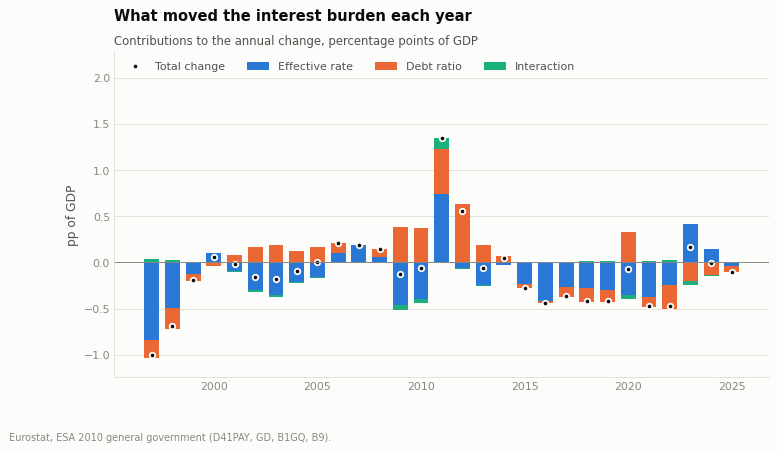

In [6]:
labels = {
    "rate_effect_pp": ("Effective rate", nb.SERIES[0]),
    "average_debt_ratio_effect_pp": ("Debt ratio", nb.SERIES[1]),
    "interaction_effect_pp": ("Interaction", nb.SERIES[2]),
}

fig, ax = nb.figure(height=4.8)
years = burden.index.to_numpy()
positive = np.zeros(len(burden))
negative = np.zeros(len(burden))
for column, (label, color) in labels.items():
    series = burden[column].to_numpy()
    base = np.where(series >= 0, positive, negative)
    ax.bar(years, series, bottom=base, color=color, width=0.72, label=label)
    positive = positive + np.where(series >= 0, series, 0.0)
    negative = negative + np.where(series < 0, series, 0.0)

ax.plot(
    years,
    burden["calculated_interest_burden_change_pp"],
    color=nb.INK,
    linewidth=0,
    marker="o",
    markersize=4.5,
    markeredgecolor=nb.SURFACE,
    markeredgewidth=1.5,
    label="Total change",
)
ax.axhline(0, color=nb.MUTED, linewidth=0.8)
nb.headroom(ax, top=1.55)
ax.legend(loc="upper left", ncol=4)
nb.finish(
    ax,
    title="What moved the interest burden each year",
    subtitle="Contributions to the annual change, percentage points of GDP",
    ylabel="pp of GDP",
)
plt.show()

### Cumulative attribution

Annual bars answer "what happened that year". Summing them over the whole window
answers the question the project actually asks: was the fall in the burden about
the price of the debt or its size?

In [7]:
totals = burden[["calculated_interest_burden_change_pp", *components]].sum()
window = f"{int(burden.index.min())}-{int(burden.index.max())}"

summary = totals.rename("pp_of_gdp").to_frame()
summary.index = [
    "Total change in the burden",
    "Effective-rate effect",
    "Debt-ratio effect",
    "Interaction effect",
]
print(f"Window: {window}")
summary

Window: 1997-2025


,pp_of_gdp
Total change in the burden,-2.88
Effective-rate effect,-4.50
Debt-ratio effect,1.63
Interaction effect,-0.01


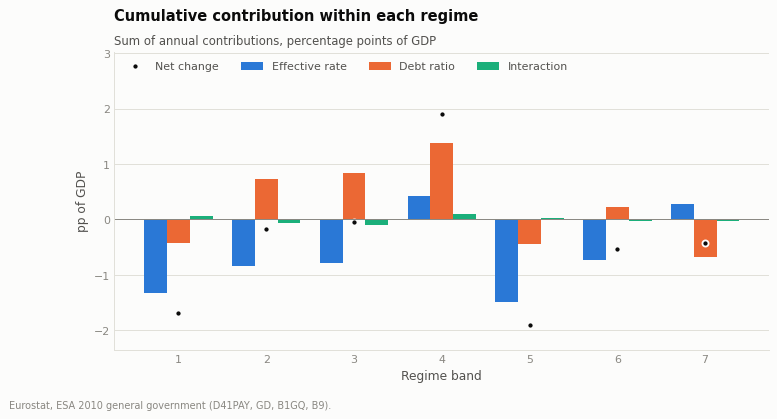

,band,first_year,last_year
regime,,,
Euro convergence,1,1995,1998
Early euro period,2,1999,2007
Global financial crisis,3,2008,2010
Sovereign-debt crisis and adjustment,4,2011,2014
ECB intervention and refinancing,5,2015,2019
Pandemic,6,2020,2021
Inflation and monetary tightening,7,2022,2025


In [8]:
by_regime = burden.groupby("regime", sort=False)[
    ["calculated_interest_burden_change_pp", *components]
].sum()
by_regime = by_regime.reindex(burden["regime"].drop_duplicates())
bands = nb.regime_spans(df)["band"]

fig, ax = nb.figure(height=4.4)
positions = np.arange(len(by_regime))
width = 0.26
for offset, (column, (label, color)) in enumerate(labels.items()):
    ax.bar(
        positions + (offset - 1) * width,
        by_regime[column],
        width=width,
        color=color,
        label=label,
    )
ax.plot(
    positions,
    by_regime["calculated_interest_burden_change_pp"],
    color=nb.INK,
    linewidth=0,
    marker="o",
    markersize=5,
    markeredgecolor=nb.SURFACE,
    markeredgewidth=1.5,
    label="Net change",
)
ax.axhline(0, color=nb.MUTED, linewidth=0.8)
ax.set_xticks(positions)
ax.set_xticklabels([str(bands.get(name, "")) for name in by_regime.index], fontsize=9)
nb.headroom(ax, top=1.45, bottom=1.12)
ax.legend(loc="upper left", ncol=4)
nb.finish(
    ax,
    title="Cumulative contribution within each regime",
    subtitle="Sum of annual contributions, percentage points of GDP",
    ylabel="pp of GDP",
    xlabel="Regime band",
)
plt.show()

nb.regime_spans(df)

## 3. Why the debt ratio moved

The debt-ratio identity, as the pipeline implements it:

$$\Delta d_t = \underbrace{\frac{r_t - g_t}{1 + g_t} \, d_{t-1}}_{\text{interest-growth contribution}}
\; \underbrace{- \, pb_t}_{\text{primary balance}} \; + \; \underbrace{sfa_t}_{\text{stock-flow adjustment}}$$

with $g_t$ nominal GDP growth and $r_t$ the **inherited-debt** rate from section
1. The stock-flow adjustment is the residual that makes the identity hold, so it
absorbs everything the accrual balance does not explain — privatisations, bank
recapitalisations, cash-buffer changes, valuation effects. It is a bookkeeping
term, not a behavioural one, and a large one is a prompt to look further rather
than a finding in itself.

The pipeline persists its own reconciliation error, so the identity can be
checked rather than assumed.

In [9]:
dynamics_components = [
    "interest_growth_contribution_pp",
    "primary_balance_contribution_pp",
    "stock_flow_adjustment_pp",
]
dynamics = df.dropna(subset=[*dynamics_components, "observed_debt_ratio_change_pp"]).set_index(
    "year"
)

reconciliation_error = df["debt_dynamics_reconciliation_error_pp"].abs().max()
print(f"Debt-dynamics reconciliation error, largest: {reconciliation_error:.3e} pp")
assert reconciliation_error < 1e-9, "debt-dynamics identity does not close"

dynamics[["observed_debt_ratio_change_pp", *dynamics_components]].tail(8)

Debt-dynamics reconciliation error, largest: 4.441e-16 pp


,observed_debt_ratio_change_pp,interest_growth_contribution_pp,primary_balance_contribution_pp,stock_flow_adjustment_pp
year,,,,
2018,-4.90,-2.51,-2.90,0.51
2019,-5.00,-2.46,-3.00,0.46
2020,18.00,10.61,3.00,4.39
2021,-10.20,-7.21,0.40,-3.39
2022,-12.70,-12.06,-1.60,0.96
2023,-14.30,-8.80,-3.20,-2.30
2024,-3.40,-4.45,-2.60,3.65
2025,-3.80,-3.23,-2.60,2.03


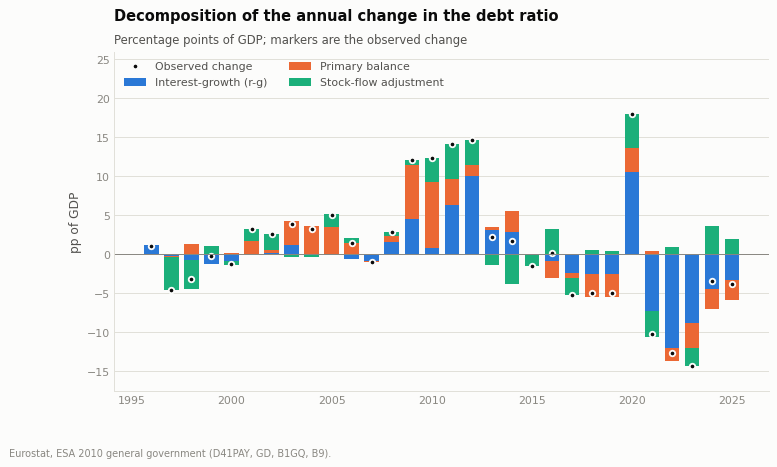

In [10]:
dynamics_labels = {
    "interest_growth_contribution_pp": ("Interest-growth (r-g)", nb.SERIES[0]),
    "primary_balance_contribution_pp": ("Primary balance", nb.SERIES[1]),
    "stock_flow_adjustment_pp": ("Stock-flow adjustment", nb.SERIES[2]),
}

fig, ax = nb.figure(height=5.0)
years = dynamics.index.to_numpy()
positive = np.zeros(len(dynamics))
negative = np.zeros(len(dynamics))
for column, (label, color) in dynamics_labels.items():
    series = dynamics[column].to_numpy()
    base = np.where(series >= 0, positive, negative)
    ax.bar(years, series, bottom=base, color=color, width=0.72, label=label)
    positive = positive + np.where(series >= 0, series, 0.0)
    negative = negative + np.where(series < 0, series, 0.0)

ax.plot(
    years,
    dynamics["observed_debt_ratio_change_pp"],
    color=nb.INK,
    linewidth=0,
    marker="o",
    markersize=4.5,
    markeredgecolor=nb.SURFACE,
    markeredgewidth=1.5,
    label="Observed change",
)
ax.axhline(0, color=nb.MUTED, linewidth=0.8)
nb.headroom(ax, top=1.32, bottom=1.10)
ax.legend(loc="upper left", ncol=2)
nb.finish(
    ax,
    title="Decomposition of the annual change in the debt ratio",
    subtitle="Percentage points of GDP; markers are the observed change",
    ylabel="pp of GDP",
)
plt.show()

In [11]:
debt_totals = dynamics[["observed_debt_ratio_change_pp", *dynamics_components]].sum()
debt_summary = debt_totals.rename("pp_of_gdp").to_frame()
debt_summary.index = [
    "Observed change in the debt ratio",
    "Interest-growth contribution",
    "Primary-balance contribution",
    "Stock-flow adjustment",
]
opening_year = int(dynamics.index.min()) - 1
opening_ratio = df.loc[df["year"].eq(opening_year), "debt_pct_gdp"].iloc[0]
print(
    f"Window: {int(dynamics.index.min())}-{int(dynamics.index.max())}  "
    f"debt ratio {opening_ratio:.1f}% -> "
    f"{dynamics['debt_pct_gdp'].iloc[-1]:.1f}% of GDP"
)
debt_summary

Window: 1996-2025  debt ratio 62.2% -> 89.7% of GDP


,pp_of_gdp
Observed change in the debt ratio,27.50
Interest-growth contribution,-5.96
Primary-balance contribution,23.50
Stock-flow adjustment,9.96


## 4. The interest-growth differential

$r - g$ is the switch that decides whether inherited debt grows or shrinks on
its own. Positive years require a primary surplus just to hold the ratio flat;
negative years do that work unaided. The colouring is on the sign, and the
midpoint is genuinely "nothing happens".

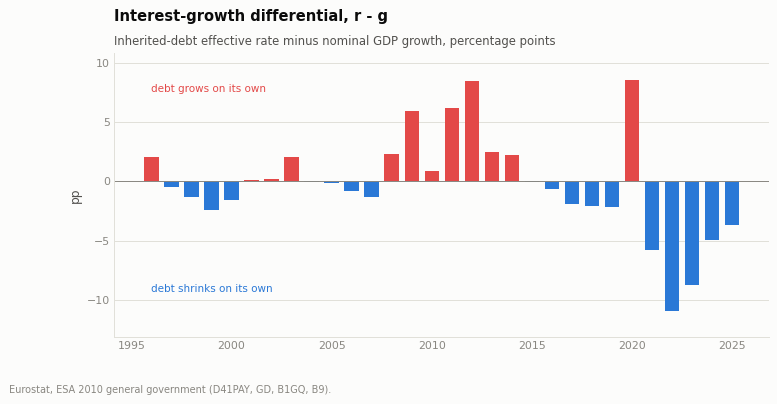

,value
years with r > g,12.00
years with r < g,18.00
mean r - g (whole period),-0.25
mean r - g (2015 onward),-2.94
mean r - g (2022 onward),-7.08


In [12]:
differential = df.dropna(subset=["interest_growth_differential_pct"]).set_index("year")
values = differential["interest_growth_differential_pct"]

fig, ax = nb.figure(height=4.2)
ax.bar(
    values.index,
    values.to_numpy(),
    color=nb.signed_colors(values.to_numpy()),
    width=0.72,
)
ax.axhline(0, color=nb.MUTED, linewidth=0.8)
nb.headroom(ax, top=1.14, bottom=1.10)
ax.annotate(
    "debt grows on its own",
    xy=(values.index.min(), values.max() * 0.88),
    fontsize=8.5,
    color=nb.POSITIVE,
    ha="left",
)
ax.annotate(
    "debt shrinks on its own",
    xy=(values.index.min(), values.min() * 0.85),
    fontsize=8.5,
    color=nb.NEGATIVE,
    ha="left",
)
nb.finish(
    ax,
    title="Interest-growth differential, r - g",
    subtitle=("Inherited-debt effective rate minus nominal GDP growth, percentage points"),
    ylabel="pp",
)
plt.show()

pd.Series(
    {
        "years with r > g": int((values > 0).sum()),
        "years with r < g": int((values < 0).sum()),
        "mean r - g (whole period)": round(values.mean(), 2),
        "mean r - g (2015 onward)": round(values.loc[values.index >= 2015].mean(), 2),
        "mean r - g (2022 onward)": round(values.loc[values.index >= 2022].mean(), 2),
    },
    name="value",
).to_frame()

## 5. The primary balance required to stabilise debt

The debt-stabilising primary balance is the surplus that exactly offsets the
interest-growth contribution. It is the *before-SFA* requirement: it assumes the
stock-flow adjustment is zero, which section 3 shows it rarely is. Plotting it
against the actual primary balance turns the identity into a reading of the
fiscal stance — above the line the ratio falls, below it the ratio rises.

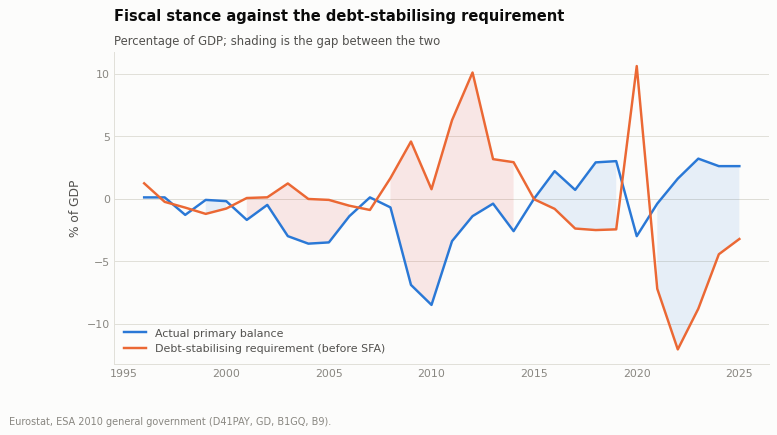

,value
years above the requirement,14.00
years below the requirement,16.00
"mean gap, whole period (pp)",-0.58
"mean gap, 2015 onward (pp)",4.43


In [13]:
stance = df.dropna(subset=["debt_stabilising_primary_balance_before_sfa_pct_gdp"]).set_index("year")
required = stance["debt_stabilising_primary_balance_before_sfa_pct_gdp"]
actual = stance["primary_balance_pct_gdp"]
gap = actual - required

fig, ax = nb.figure(height=4.6)
ax.plot(stance.index, actual, color=nb.SERIES[0], label="Actual primary balance")
ax.plot(
    stance.index,
    required,
    color=nb.SERIES[1],
    label="Debt-stabilising requirement (before SFA)",
)
ax.fill_between(
    stance.index,
    actual,
    required,
    where=gap >= 0,
    color=nb.SERIES[0],
    alpha=0.10,
    linewidth=0,
)
ax.fill_between(
    stance.index,
    actual,
    required,
    where=gap < 0,
    color=nb.SERIES[7],
    alpha=0.12,
    linewidth=0,
)
ax.axhline(0, color=nb.MUTED, linewidth=0.8, zorder=0)
ax.legend(loc="lower left")
nb.finish(
    ax,
    title="Fiscal stance against the debt-stabilising requirement",
    subtitle="Percentage of GDP; shading is the gap between the two",
    ylabel="% of GDP",
)
plt.show()

pd.Series(
    {
        "years above the requirement": int((gap >= 0).sum()),
        "years below the requirement": int((gap < 0).sum()),
        "mean gap, whole period (pp)": round(gap.mean(), 2),
        "mean gap, 2015 onward (pp)": round(gap.loc[gap.index >= 2015].mean(), 2),
    },
    name="value",
).to_frame()

## 6. Findings

Generated from the frames above.

In [14]:
recent = burden.loc[burden.index >= 2015]
crisis = burden.loc[burden.index.isin(range(2009, 2015))]

print(f"Burden decomposition, {window}")
print(
    f"  total {totals['calculated_interest_burden_change_pp']:+.2f} pp = "
    f"rate {totals['rate_effect_pp']:+.2f} "
    f"+ debt ratio {totals['average_debt_ratio_effect_pp']:+.2f} "
    f"+ interaction {totals['interaction_effect_pp']:+.2f}"
)
print(
    "  crisis 2009-2014: total "
    f"{crisis['calculated_interest_burden_change_pp'].sum():+.2f} pp "
    f"(rate {crisis['rate_effect_pp'].sum():+.2f}, "
    f"debt ratio {crisis['average_debt_ratio_effect_pp'].sum():+.2f})"
)
print(
    "  since 2015      : total "
    f"{recent['calculated_interest_burden_change_pp'].sum():+.2f} pp "
    f"(rate {recent['rate_effect_pp'].sum():+.2f}, "
    f"debt ratio {recent['average_debt_ratio_effect_pp'].sum():+.2f})"
)
print()
print(f"Debt-ratio decomposition, {int(dynamics.index.min())}-{int(dynamics.index.max())}")
print(
    f"  observed {debt_totals['observed_debt_ratio_change_pp']:+.1f} pp = "
    f"r-g {debt_totals['interest_growth_contribution_pp']:+.1f} "
    f"+ primary balance {debt_totals['primary_balance_contribution_pp']:+.1f} "
    f"+ SFA {debt_totals['stock_flow_adjustment_pp']:+.1f}"
)
print(f"  years with r > g: {int((values > 0).sum())} of {len(values)}")

Burden decomposition, 1997-2025
  total -2.88 pp = rate -4.50 + debt ratio +1.63 + interaction -0.01
  crisis 2009-2014: total +1.70 pp (rate -0.43, debt ratio +2.13)
  since 2015      : total -2.87 pp (rate -1.95, debt ratio -0.89)

Debt-ratio decomposition, 1996-2025
  observed +27.5 pp = r-g -6.0 + primary balance +23.5 + SFA +10.0
  years with r > g: 12 of 30


**Reading.** Over the whole window the fall in the burden is a *price* story and
nothing else. The effective-rate effect is larger than the total fall, and the
debt-ratio effect works in the opposite direction — the debt stock relative to
GDP is higher at the end of the window than at the start, and on its own that
would have raised the burden. Cheaper debt more than paid for more debt.

The debt ratio itself gives the complementary account: the interest-growth
differential was *favourable* on net across the window, so the build-up came
from cumulative primary deficits and from a large positive stock-flow
adjustment, not from the arithmetic of compounding interest.

**Caveats.** The stock-flow adjustment is a residual, and a cumulative total of
this size is a question rather than an answer — it points at crisis-era bank
support, programme cash buffers, and privatisations rather than explaining them.
The debt-stabilising line in section 5 sets the adjustment to zero, so it
understates the primary balance actually needed in years when it was positive.

**Next.** [04 — pass-through and scenarios](04_rate_pass_through_and_scenarios.ipynb)
asks how fast a change in market yields reaches the effective rate, and what
that implies for rate shocks.